# Phase 1 — Data Audit & Feasibility
## Steam Games Intelligence

**Scope of this notebook:** audit the two raw Steam datasets, understand their *actual* schema and quality (not the documented one), identify temporal/leakage risk, and issue a GO/MODIFY/DROP call for each of four proposed downstream modules.

**Explicitly out of scope for this notebook:** predictive modeling, NLP models, embeddings, topic modeling, recommendation systems, final target/threshold selection. Those are Phase 2+ decisions and are only informed, not made, here.

Written findings live in [`outputs/feasibility_summary.md`](../outputs/feasibility_summary.md).

In [1]:
import sys
sys.path.insert(0, "../src")

import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from audit_utils import (
    GAMES_PATH, REVIEWS_PATH,
    load_games, load_reviews,
    parse_list_field, estimated_owners_format, parse_estimated_owners,
    parse_review_quotes, attribution_to_outlet, top_items,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.facecolor"] = "white"
SNAPSHOT_DATE = pd.Timestamp("2026-08-28")
FIG_DIR = "../figures/phase1"


## 1. Load & size the data

**Question:** How large are these files, and do they fit comfortably in memory on an 8 GB machine?

In [2]:
import os

for path in [GAMES_PATH, REVIEWS_PATH]:
    print(f"{os.path.basename(path):28s} {os.path.getsize(path)/1e6:8.1f} MB")


steam_games.csv                 917.1 MB
steam_games_reviews.csv           4.8 MB


In [3]:
games = load_games()
reviews = load_reviews()

print("games  :", games.shape, f"-> {games.memory_usage(deep=True).sum()/1e6:.0f} MB in memory")
print("reviews:", reviews.shape, f"-> {reviews.memory_usage(deep=True).sum()/1e6:.0f} MB in memory")


games  : (139076, 42) -> 937 MB in memory
reviews: (13039, 3) -> 5 MB in memory


**Result:** `steam_games.csv` is 917 MB on disk / ~938 MB loaded (139,076 rows × 42 columns); `steam_games_reviews.csv` is 4.8 MB / ~5 MB (13,039 rows × 3 columns). Both load as a single `read_csv` in well under a minute and comfortably fit in 8 GB RAM — no chunking or streaming infrastructure is needed for Phase 1.

**Interpretation:** resource constraints are not a blocker for this project at its current size; efficiency work (dtype downcasting, avoiding repeated JSON parses) is a nice-to-have here, not a requirement.

## 2. Main data audit: identifiers, schema, missingness

**Question:** Is `app_id` a safe unique key? What does the column-by-column missingness picture look like?

In [4]:
print("app_id unique:", games['app_id'].is_unique, "| n_unique:", games['app_id'].nunique())
print("duplicate rows:", games.duplicated().sum())
print("name unique:", games['name'].nunique(), "of", len(games), "-> duplicated names:", games['name'].duplicated().sum())
games[games['name'].duplicated(keep=False)].sort_values('name')[['app_id','name']].head(6)


app_id unique: True | n_unique: 139076


duplicate rows: 0
name unique: 137664 of 139076 -> duplicated names: 1411


,app_id,name
63278,3022780,A Better Tomorrow
79057,3763930,A Better Tomorrow
99665,557900,A Walk in the Woods
105333,842420,A Walk in the Woods
22746,1544540,ALONE
31488,1826070,ALONE


In [5]:
miss_pct = (games.isna().mean() * 100).sort_values(ascending=False)
miss_pct.head(12).to_frame("pct_missing").round(2)


,pct_missing
metacritic_url,96.92
notes,81.28
website,61.03
support_url,56.84
metacritic_score,26.80
recommendations,21.91
full_audio_languages,21.17
support_email,17.31
achievements,11.68
about_the_game,6.07


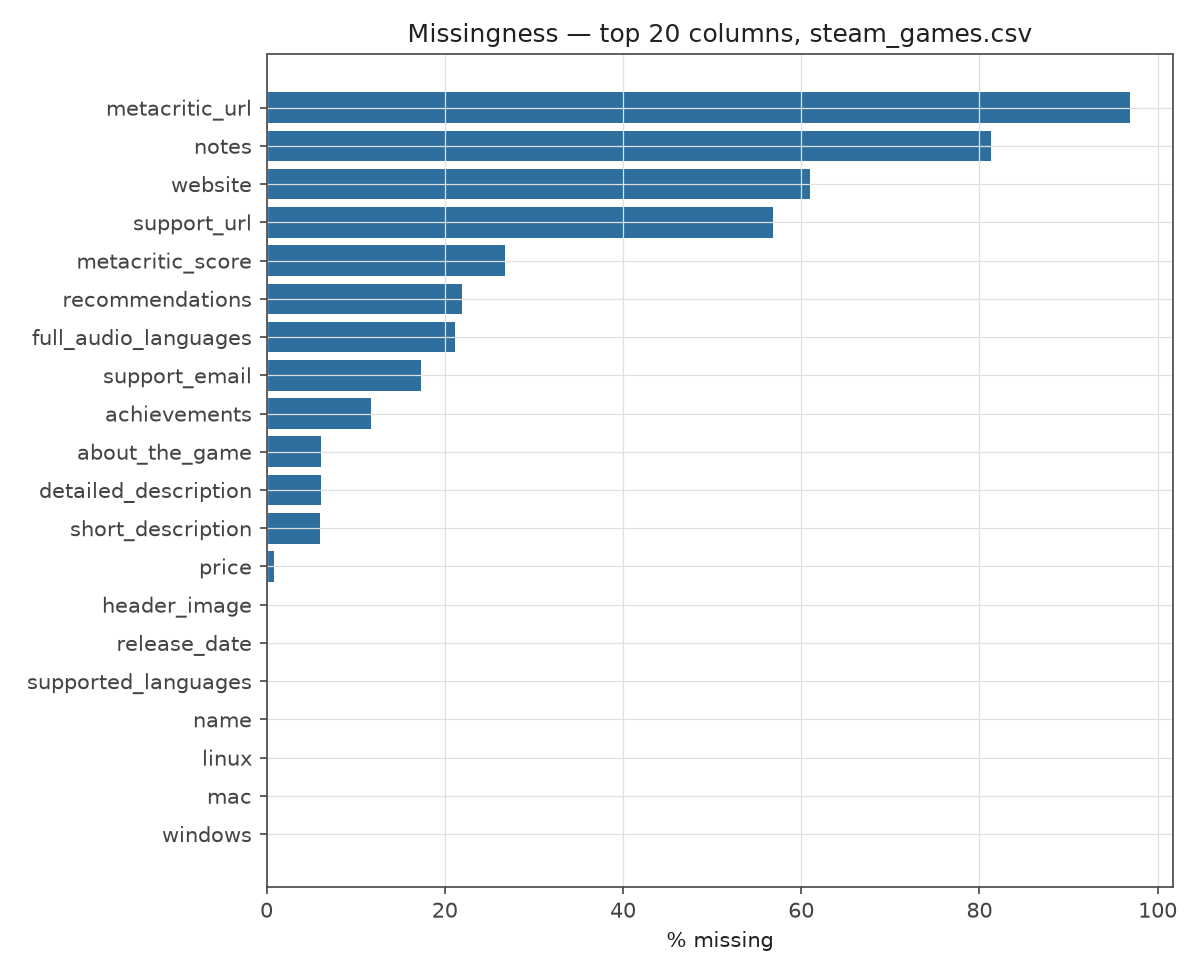

In [6]:
from IPython.display import Image
Image(filename=f"{FIG_DIR}/02_missingness_top20.png")


**Result:** `app_id` is unique in both files (0 duplicates) — it is the correct join key. `name` is **not** safe as a key (137,664 unique names across 139,076 rows; 1,411 duplicates). 0 fully duplicate rows. The most-missing columns are largely optional store metadata (`metacritic_url` 96.9%, `notes` 81.3%) plus meaningful outcome fields (`metacritic_score` 26.8%, `recommendations` 21.9%).

**Interpretation:** joins should always use `app_id`. Missingness is concentrated in fields we'd expect to be sparse (URLs, notes) plus a few outcome columns that will need explicit missing-value handling before any later modeling.

## 3. Release dates & catalog growth

**Question:** Does `release_date` parse cleanly, and what does the shape of the catalog over time look like?

In [7]:
rd = pd.to_datetime(games['release_date'], errors='coerce')
games['_release_dt'] = rd
games['_release_year'] = rd.dt.year

print("parses:", rd.notna().sum(), "/", len(games), " fails:", rd.isna().sum())
print("range:", rd.min(), "to", rd.max())
print("future (> snapshot date) rows:", (rd > SNAPSHOT_DATE).sum())


parses: 138993 / 139076  fails: 83
range: 1997-06-30 00:00:00 to 2026-08-25 00:00:00
future (> snapshot date) rows: 0


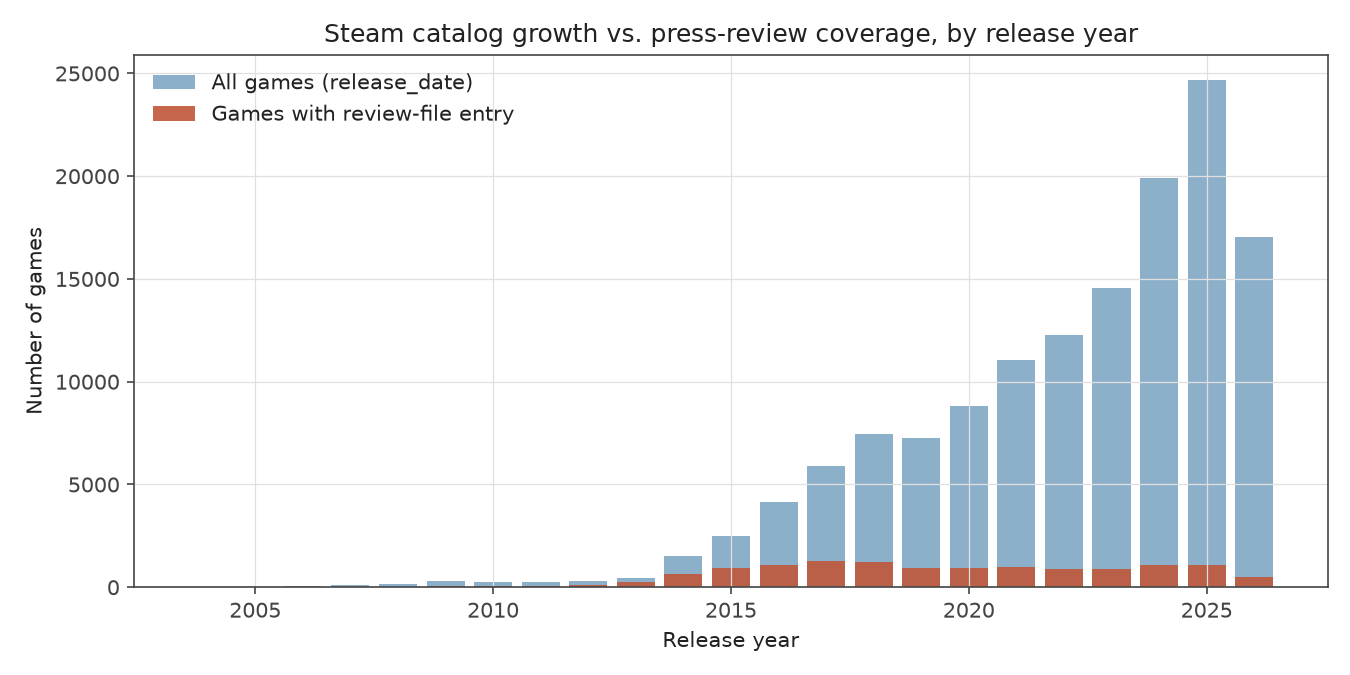

In [8]:
Image(filename=f"{FIG_DIR}/01_releases_and_review_coverage_by_year.png")


**Result:** 138,993/139,076 rows (99.9%) parse to a valid date, ranging 1997-06-30 to 2026-08-25 with no dates beyond the snapshot. Catalog growth is extreme: from single/double digits per year before 2010 to 24,687 releases in 2025 alone; **2024–2026 account for ~44% of the entire catalog.**

**Interpretation:** this dataset is dominated by very recent, low-history releases. Any outcome variable that accumulates over time (owners, reviews, playtime) will be structurally small for the majority of rows simply because most rows are new — this foreshadows the exposure-time analysis in Section 8.

## 4. `steam_store_available` / `steam_spy_available`

**Question:** Are these availability/source flags informative, and do they explain any of the schema inconsistencies discovered below?

In [9]:
print(games['steam_store_available'].value_counts(dropna=False))
print()
print(games['steam_spy_available'].value_counts(dropna=False))


steam_store_available
True     139061
False        15
Name: count, dtype: int64

steam_spy_available
True    139076
Name: count, dtype: int64


**Result:** `steam_store_available` is `True` for 139,061/139,076 rows. `steam_spy_available` is `True` for **all** rows — a constant column in this snapshot.

**Interpretation:** `steam_spy_available` has zero discriminative value here (the raw source may already be pre-filtered to SteamSpy-available titles — an open question for Phase 2). Neither flag turns out to explain the dual-format schema issue found next.

## 5. Semantic field audit: `genres` / `categories` / `tags` / `developers` / `publishers`

**Question:** What is the actual serialization format of these list-like fields, and how concentrated is the vocabulary?

In [10]:
def fmt_type(s):
    if pd.isna(s):
        return 'null'
    s = str(s).strip()
    if s in ('', '[]'):
        return 'empty'
    return 'dict_list' if s.startswith('[{') else 'str_list'

genre_fmt = games['genres'].apply(fmt_type).value_counts()
owners_fmt = games['estimated_owners'].apply(estimated_owners_format).value_counts()
print("genres serialization formats:\n", genre_fmt, "\n")
print("estimated_owners delimiter formats:\n", owners_fmt)


genres serialization formats:
 genres
str_list     101126
dict_list     29518
empty          8432
Name: count, dtype: int64 

estimated_owners delimiter formats:
 estimated_owners
dash      98685
dotdot    40391
Name: count, dtype: int64


In [11]:
cross = pd.crosstab(games['genres'].apply(fmt_type), games['estimated_owners'].apply(estimated_owners_format))
cross


estimated_owners,dash,dotdot
genres,,
dict_list,0,29518
empty,8359,73
str_list,90326,10800


**Result — schema inconsistency:** `genres`/`categories` are serialized two different ways in the same column: a plain string list (`["Action","Adventure"]`, ~101k rows) and a raw Steam-API dict list (`[{"id":"4","description":"Casual"}]`, ~29.5k rows). That dict-list subset lines up almost exactly with the rows where `estimated_owners` uses a `"lo .. hi"` comma-delimited format instead of `"lo - hi"`.

**Interpretation:** this is strong evidence the file is a **merge of at least two differently-formatted source extracts** that was never fully normalized — not random noise. `src/audit_utils.py::parse_list_field` normalizes both formats to a flat string list; this parser is used for everything below.

In [12]:
for col in ['genres', 'categories', 'tags', 'developers', 'publishers']:
    parsed = games[col].apply(parse_list_field)
    lengths = parsed.apply(lambda v: len(v) if isinstance(v, list) else np.nan)
    n_items = len(set(x for v in parsed if isinstance(v, list) for x in v))
    print(f"{col:12s} median_len={lengths.median():.0f}  max_len={lengths.max():.0f}  zero_len={(lengths==0).sum():6d}  n_unique_items={n_items}")


genres       median_len=3  max_len=19  zero_len=  8432  n_unique_items=43


categories   median_len=4  max_len=34  zero_len=  8963  n_unique_items=98


tags         median_len=4  max_len=21  zero_len= 55624  n_unique_items=451


developers   median_len=1  max_len=41  zero_len=  8449  n_unique_items=86963


publishers   median_len=1  max_len=10  zero_len=  8846  n_unique_items=73219


In [13]:
genres_parsed = games['genres'].apply(parse_list_field)
pd.DataFrame(top_items(genres_parsed, 10), columns=['genre', 'n_games'])


,genre,n_games
0,Indie,92478
1,Casual,58162
2,Action,51880
3,Adventure,50524
4,Simulation,28337
5,Strategy,26235
6,RPG,23941
7,Free To Play,14254
8,Early Access,12900
9,Sports,5435


**Result:** `genres` — median 3 per game, 43 unique labels, dominated by Indie (92,478 games), Casual, Action, Adventure. `categories` — median 4 per game, 98 unique labels, dominated by Single-player and Family Sharing. `tags` — 40% of games have zero tags; among the rest, median 4, 451 unique tags. `developers`/`publishers` — median 1 each, 86,963 / 73,219 unique values respectively (long-tail; a few high-volume names like `EroticGamesClub` and `BFG Entertainment` dominate the counts).

**Interpretation:** genres/categories/tags are usable, well-populated content signals for market analytics and content-based similarity once the dual-format issue is normalized. `tags` needs a "missing" strategy since 40% of games have none.

## 6. Price audit

**Question:** How is `price` distributed, and is it consistent with `price_status`? Remember: this is *current* price, not necessarily launch price.

In [14]:
print(games['price'].describe(percentiles=[.5, .75, .9, .95, .99]).round(2))
print()
print("zero-price rows:", (games['price'] == 0).sum(), " | missing:", games['price'].isna().sum())
games.nlargest(3, 'price')[['app_id', 'name', 'price', 'price_status']]


count    137927.00
mean          9.03
std         411.83
min           0.00
50%           4.99
75%           9.99
90%          16.99
95%          19.99
99%          49.99
max      107500.00
Name: price, dtype: float64

zero-price rows: 27741  | missing: 1149


,app_id,name,price,price_status
139041,4614980,The Honored Wife,107500.0,paid
139045,4633540,Soft Money,107500.0,paid
139039,4598070,Strict Sensei,16000.0,paid


In [15]:
pd.crosstab(games['price_status'], games['price'] == 0)


price,False,True
price_status,,
free,668,27389
paid,107293,0
unavailable,3374,352


**Result:** heavy right skew (mean \$9.03 vs median \$4.99), driven by genuine outliers (two titles priced at \$107,500). `price_status` is mostly consistent with `price == 0` meaning "free," but 668 `"free"` rows carry a nonzero price and 3,374 `"unavailable"` rows carry a nonzero (likely stale) price.

**Interpretation:** `price` needs a log-transform or outlier cap before any distributional use, and must be treated as **temporally ambiguous** (current, not launch) rather than launch-known, per the project's methodological constraints.

## 7. `estimated_owners`, and review/engagement outcome variables

**Question:** What is the actual granularity of `estimated_owners`, and how do the review/engagement outcome columns relate to each other?

In [16]:
print("unique bucket values:", games['estimated_owners'].nunique())
games['estimated_owners'].value_counts(dropna=False).head(10)


unique bucket values: 27


estimated_owners
0 - 20000             63332
0 .. 20,000           28928
0 - 0                 21193
20000 - 50000          7451
20,000 .. 50,000       3959
50000 - 100000         3041
50,000 .. 100,000      2328
100,000 .. 200,000     1767
200,000 .. 500,000     1708
100000 - 200000        1702
Name: count, dtype: int64

In [17]:
owners_parsed = games['estimated_owners'].apply(parse_estimated_owners)
games['_owners_lo'] = [t[0] for t in owners_parsed]
games['_owners_hi'] = [t[1] for t in owners_parsed]
games['_owners_mid'] = [t[2] for t in owners_parsed]

bottom_bucket_share = (games['_owners_hi'] <= 20000).mean()
print(f"share of catalog in the bottom 1-2 owner buckets (hi <= 20,000): {bottom_bucket_share:.1%}")


share of catalog in the bottom 1-2 owner buckets (hi <= 20,000): 81.6%


**Result:** `estimated_owners` has only **27 unique bucket values** across the whole catalog, and ~82% of all games fall in just the bottom one or two buckets (`"0-0"` or the `0–20,000` equivalent, across both delimiter formats). A `lo`/`hi`/`mid` parse is shown above purely to illustrate the field's format — this is **not** a final modeling representation.

**Interpretation:** as a continuous popularity proxy, `estimated_owners` is extremely coarse for the (large) majority of the catalog. `positive`/`negative`/`recommendations` likely carry more usable variance for popularity — checked next.

In [18]:
games['_total_reviews'] = games['positive'].fillna(0) + games['negative'].fillna(0)
games['_pos_ratio'] = np.where(games['_total_reviews'] > 0, games['positive'] / games['_total_reviews'], np.nan)

outcome_cols = ['positive', 'negative', 'recommendations', 'peak_ccu', 'average_playtime_forever', '_owners_mid', '_total_reviews']
games[outcome_cols].describe(percentiles=[.5, .9, .95, .99]).round(1).T


,count,mean,std,min,50%,90%,95%,99%,max
positive,139076.0,921.6,26378.6,0.0,3.0,226.0,864.0,11272.8,7642084.0
negative,139076.0,149.3,5046.8,0.0,0.0,57.0,184.0,1838.2,1173003.0
recommendations,108611.0,1135.8,24351.1,0.0,0.0,419.0,1423.0,15070.5,5179195.0
peak_ccu,139076.0,48.2,3501.9,0.0,0.0,1.0,7.0,183.0,1013936.0
average_playtime_forever,139076.0,81.9,2011.7,0.0,0.0,0.0,168.0,1245.0,359665.0
_owners_mid,139076.0,76854.6,1211187.0,0.0,10000.0,75000.0,150000.0,750000.0,150000000.0
_total_reviews,139076.0,1070.9,30646.5,0.0,4.0,295.0,1079.0,13475.2,8815087.0


In [19]:
zero_inflation = {c: round((games[c].fillna(0) == 0).mean(), 3) for c in ['positive', 'negative', 'recommendations', 'average_playtime_forever', '_total_reviews']}
print("zero-inflation rate:", zero_inflation)
print()
games[['positive', 'negative', 'recommendations', 'peak_ccu', 'average_playtime_forever', '_owners_mid']].corr(numeric_only=True).round(2)


zero-inflation rate: {'positive': np.float64(0.422), 'negative': np.float64(0.514), 'recommendations': np.float64(0.841), 'average_playtime_forever': np.float64(0.914), '_total_reviews': np.float64(0.403)}



,positive,negative,recommendations,peak_ccu,average_playtime_forever,_owners_mid
positive,1.00,0.82,0.91,0.85,0.01,0.74
negative,0.82,1.00,0.74,0.83,0.02,0.77
recommendations,0.91,0.74,1.00,0.67,0.02,0.63
peak_ccu,0.85,0.83,0.67,1.00,0.02,0.64
average_playtime_forever,0.01,0.02,0.02,0.02,1.00,0.03
_owners_mid,0.74,0.77,0.63,0.64,0.03,1.00


**Result:** `positive`/`negative`/`recommendations`/`peak_ccu`/owners-midpoint are strongly inter-correlated (r = 0.72–0.99) — largely redundant measures of one underlying "popularity" factor. `average_playtime_forever` is nearly uncorrelated with `positive` (r = 0.01) and is 91.4% zero. `recommendations` is 84.1% zero-inflated among non-missing values (plus 21.9% missing outright).

**Interpretation:** these fields are heavily skewed, zero-inflated, and partly redundant. Any future use needs log-transforms and a chosen primary metric rather than using all of them independently — but that choice belongs in Phase 2, not here.

## 8. Temporal / exposure-time confound

**Question:** Do older games show higher cumulative outcomes simply because they've had longer to accumulate them?

In [20]:
games['_age_years'] = (SNAPSHOT_DATE - games['_release_dt']).dt.days / 365.25
naive_corr = games[['_age_years', '_owners_mid', '_total_reviews', 'positive']].corr(numeric_only=True)['_age_years']
print("naive Pearson correlation of age with outcomes:\n", naive_corr.round(3))


naive Pearson correlation of age with outcomes:
 _age_years        1.000
_owners_mid       0.081
_total_reviews    0.049
positive          0.050
Name: _age_years, dtype: float64


In [21]:
yr = games[(games['_release_year'] >= 2010) & (games['_release_year'] <= 2026)]
by_year = yr.groupby('_release_year').agg(
    n_games=('app_id', 'count'),
    median_total_reviews=('_total_reviews', 'median'),
    median_owners_mid=('_owners_mid', 'median'),
).round(0)
by_year


,n_games,median_total_reviews,median_owners_mid
_release_year,,,
2010.0,255,408.0,75000.0
2011.0,258,834.0,150000.0
2012.0,322,1110.0,350000.0
2013.0,467,1170.0,150000.0
2014.0,1521,316.0,75000.0
2015.0,2513,156.0,35000.0
2016.0,4137,88.0,35000.0
2017.0,5918,39.0,10000.0
2018.0,7451,27.0,10000.0


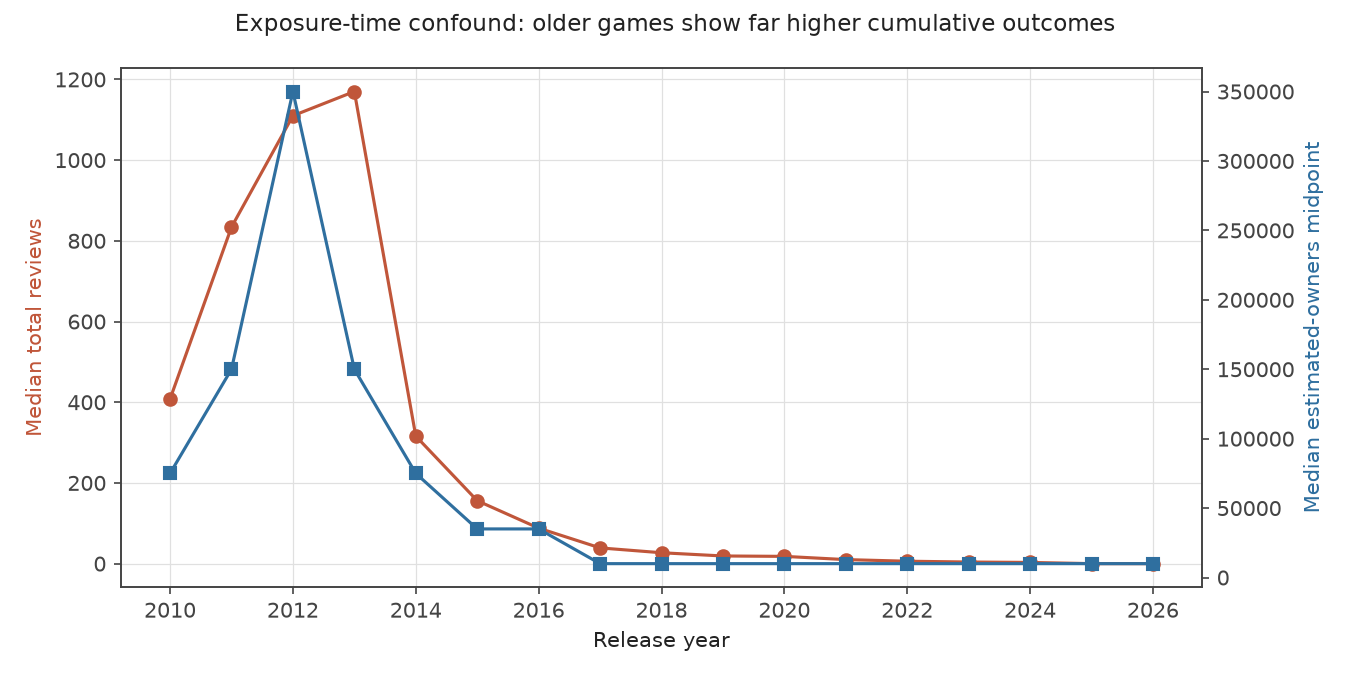

In [22]:
Image(filename=f"{FIG_DIR}/05_outcome_vs_release_year_exposure_time.png")


**Result:** the naive Pearson correlation between age and outcomes looks weak (0.02–0.05) — but that's an artifact of the catalog's shape: recent low-variance releases vastly outnumber older ones, diluting the coefficient. The release-year-**stratified median** tells the real story: median total reviews falls from >1,000 for 2011–2013 cohorts to essentially 0 for 2025–2026 cohorts, tracking almost perfectly with how long a game has been listed.

**Interpretation:** this is a severe, confirmed exposure-time confound. **Any model trained on the full catalog using current-cumulative targets will substantially learn "how long has this game been listed," not "was this game successful."** This directly shapes the Success Modeling verdict in Section 12 — raw current-cumulative outcomes cannot be used as a naive prediction target.

## 9. Review file: schema reveal

**Question:** What does `steam_games_reviews.csv` actually contain? The documentation describes up to ~100 English-language Steam user reviews per game in JSON.

In [23]:
print(reviews.shape)
print(reviews.dtypes)
print("app_id unique:", reviews['app_id'].is_unique, "| duplicate app_ids:", reviews['app_id'].duplicated().sum())
print("missing reviews field:", reviews['reviews'].isna().sum())


(13039, 3)
app_id     int64
name         str
reviews      str
dtype: object
app_id unique: True | duplicate app_ids: 0
missing reviews field: 0


In [24]:
for i in range(2):
    print(f"--- app_id {reviews.loc[i, 'app_id']} ({reviews.loc[i, 'name']}) ---")
    print(repr(reviews.loc[i, 'reviews'])[:400])
    print()


--- app_id 856080 (Mind Labyrinth VR Dreams) ---
'“Mind Labyrinth VR Dreams Gets Emotional” VR The Gamers “Mind Labyrinth Is An Idyllic New Fantasy Adventure” Upload VR “Mind Labyrinth VR Dreams angekündigt” PlayFront '

--- app_id 856100 (Little Comet) ---
'“Little Comet is a casual title that packs just enough challenge to appeal to more hardcore gamers” 7/10 – GamersHeroes '



In [25]:
import json as _json
sample = reviews['reviews'].iloc[0]
try:
    _json.loads(sample)
    print("Valid JSON")
except Exception as e:
    print("NOT valid JSON:", e)

r = reviews['reviews'].astype(str)
print("contains 'voted_up' (Steam user-review API field):", r.str.contains('voted_up', case=False).sum())
print("contains 'recommendationid' (Steam user-review API field):", r.str.contains('recommendationid', case=False).sum())
print("contains 'hrs on record' phrasing:", r.str.contains('hrs on record|hours on record', case=False).sum())


NOT valid JSON: Expecting value: line 1 column 1 (char 0)
contains 'voted_up' (Steam user-review API field): 0


contains 'recommendationid' (Steam user-review API field): 0
contains 'hrs on record' phrasing: 1


**Result:** the field is **not JSON**. Empty games are the literal string `"[]"`; non-empty games are a plain concatenated text blob of the form `"“quote text” score – outlet"`, repeated a small number of times with no delimiter between entries. Zero occurrences of the actual Steam user-review API fields (`voted_up`, `recommendationid`) anywhere in the file.

**Interpretation:** this is the Steam store page's **curated critic/press pull-quote carousel**, not the community user-review system the documentation described. There are no per-review structured fields (no rating, timestamp, playtime, helpfulness, or user id) — just quote text and an attribution string. This finding drives the rest of Section 9–10 and the Review Intelligence module verdict.

## 10. Review file: parsed quote statistics & sampling

In [26]:
r = reviews['reviews'].astype(str)
empty_mask = r.str.strip() == '[]'
print(f"empty ([]) games: {empty_mask.sum()} / {len(reviews)} ({empty_mask.mean():.1%})")

quote_lists = reviews.loc[~empty_mask, 'reviews'].apply(parse_review_quotes)
n_quotes = quote_lists.apply(len)
print()
print("quotes-per-game (non-empty games only):")
print(n_quotes.describe(percentiles=[.5, .9, .95, .99]).round(2))
print("max quotes per game:", n_quotes.max())
print("total quotes:", int(n_quotes.sum()))


empty ([]) games: 594 / 13039 (4.6%)



quotes-per-game (non-empty games only):


count    12445.00
mean         2.30
std          0.91
min          0.00
50%          3.00
90%          3.00
95%          3.00
99%          3.00
max         10.00
Name: reviews, dtype: float64
max quotes per game: 10
total quotes: 28654


In [27]:
all_quotes = [t for lst in quote_lists for t in lst]
qlen = pd.Series([len(text) for text, attr in all_quotes])
outlets = Counter(attribution_to_outlet(attr) for _, attr in all_quotes if attr.strip())

print("quote text length (chars):")
print(qlen.describe(percentiles=[.5, .9, .99]).round(1))
print()
print("unique outlet strings:", len(outlets))
pd.DataFrame(outlets.most_common(10), columns=['outlet', 'n_quotes'])


quote text length (chars):
count    28654.0
mean       124.2
std        101.4
min          0.0
50%        100.0
90%        237.0
99%        477.5
max       2754.0
dtype: float64

unique outlet strings: 10554


,outlet,n_quotes
0,PC Gamer,727
1,Rock Paper Shotgun,640
2,IGN,584
3,Destructoid,420
4,Kotaku,375
5,Eurogamer,369
6,,329
7,"Rock, Paper, Shotgun",246
8,Polygon,233
9,Hardcore Gamer,207


**Result:** 4.6% of review-file games are empty. Of the 95.4% with content, quotes per game are small — mean 2.3, median 3, **max 10** — a world away from "up to ~100 reviews." Quote text is short (median 100 characters), consistent with marketing pull-quotes, not full reviews. 10,553 distinct outlets/attributions appear, led by major games press (PC Gamer, Rock Paper Shotgun, IGN, Destructoid, Kotaku).

**Sampling mechanism:** no local evidence supports a defined sampling algorithm for player reviews, because player reviews are not present in this file at all — that framing does not apply. For the critic-quote content that *does* exist, the "selection mechanism" is Steam's own promotional curation of which quotes to feature on a store page: an inherently non-random, self-selected, generally positively-biased sample (games without press attention, or without a quotable positive line, will not be featured). **This should never be interpreted as an unbiased estimate of general sentiment about a game, let alone of the wider Steam catalog.**

## 11. Join feasibility & coverage bias

**Question:** How well do the two files join on `app_id`, and are review-covered games representative of the catalog?

In [28]:
games_ids = set(games['app_id'])
reviews_ids = set(reviews['app_id'])
matched = games_ids & reviews_ids

join_summary = pd.Series({
    'games_unique_app_ids': len(games_ids),
    'reviews_unique_app_ids': len(reviews_ids),
    'matched': len(matched),
    'games_only': len(games_ids - reviews_ids),
    'reviews_only': len(reviews_ids - games_ids),
    'match_pct_of_games': round(len(matched) / len(games_ids) * 100, 2),
})
join_summary


games_unique_app_ids      139076.00
reviews_unique_app_ids     13039.00
matched                    13039.00
games_only                126037.00
reviews_only                   0.00
match_pct_of_games             9.38
dtype: float64

In [29]:
merged_names = games[['app_id', 'name']].merge(reviews[['app_id', 'name']], on='app_id', suffixes=('_games', '_reviews'))
mismatch = merged_names[merged_names['name_games'].astype(str).str.strip() != merged_names['name_reviews'].astype(str).str.strip()]
print(f"name mismatches on matched app_id: {len(mismatch)} / {len(merged_names)}")


name mismatches on matched app_id: 0 / 13039


**Result:** cardinality is clean 1:1 — the reviews file's 13,039 app_ids are entirely a subset of the 139,076 games app_ids (0 orphaned reviews-only ids), and 0 name mismatches on the matched set. **Only 9.4% of the catalog has any press-quote entry at all**, so join correctness is not the concern here — coverage is.

In [30]:
games = games.merge(reviews.assign(_has_reviews=~empty_mask)[['app_id', '_has_reviews']], on='app_id', how='left')
games['_has_reviews'] = games['_has_reviews'].fillna(False)

cov = games.groupby('_has_reviews').agg(
    n=('app_id', 'count'),
    median_release_year=('_release_year', 'median'),
    median_price=('price', 'median'),
    pct_free=('price', lambda s: round((s == 0).mean() * 100, 1)),
    median_total_reviews=('_total_reviews', 'median'),
)
cov


,n,median_release_year,median_price,pct_free,median_total_reviews
_has_reviews,,,,,
False,126631,2023.0,3.99,21.0,2.0
True,12445,2020.0,9.99,8.9,107.0


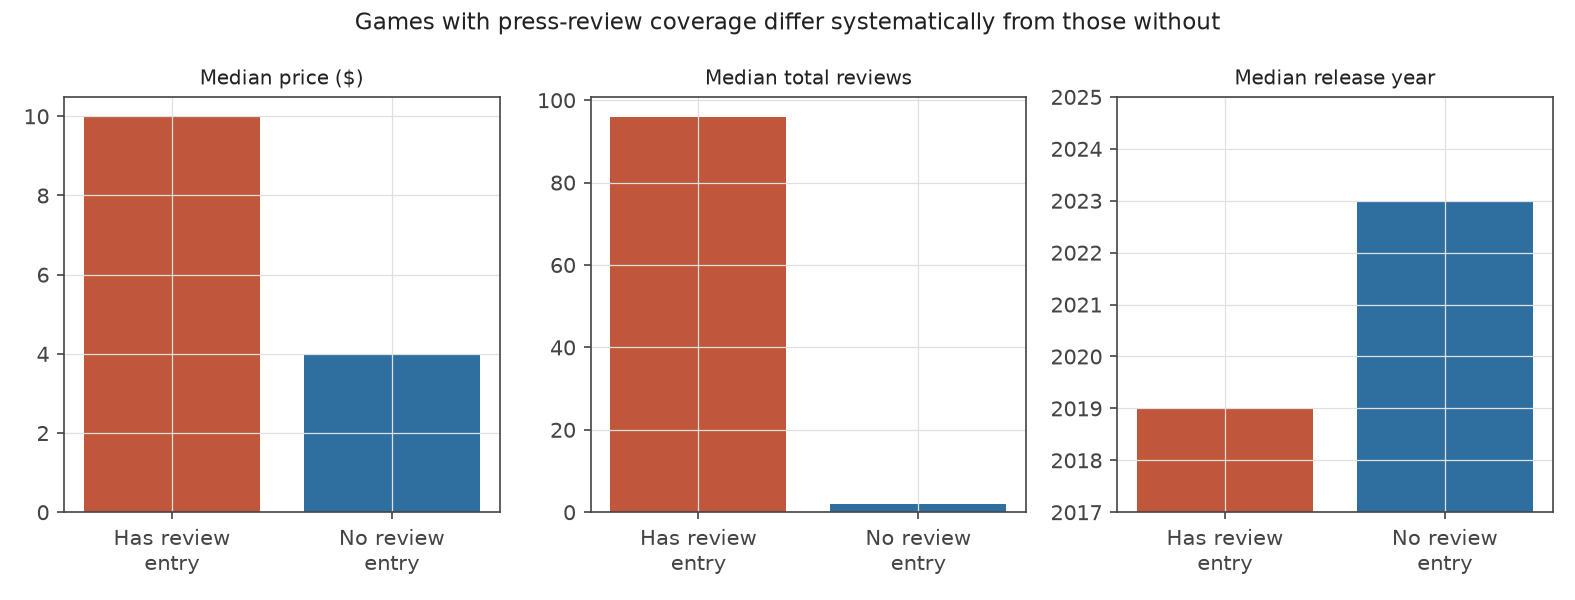

In [31]:
Image(filename=f"{FIG_DIR}/03_review_coverage_selection_bias.png")


**Result:** press-covered games skew 3 years older on the median (2020 vs 2023), 2.5x higher median price (\$9.99 vs \$3.99), less than half as likely to be free (8.9% vs 21.0%), and have >50x higher median total user reviews (107 vs 2) than the rest of the catalog. Genre mix also shifts toward Adventure/Strategy/RPG and away from Free To Play/Early Access/Casual.

**Interpretation:** press-quote coverage is a strong proxy for "got noticed by games media" — older, pricier, more narrative-genre, more established titles. Any text-based finding from this file describes *that specific slice*, not the Steam catalog broadly, and should be labeled accordingly.

## 12. Diagnostic figure: candidate outcome distributions

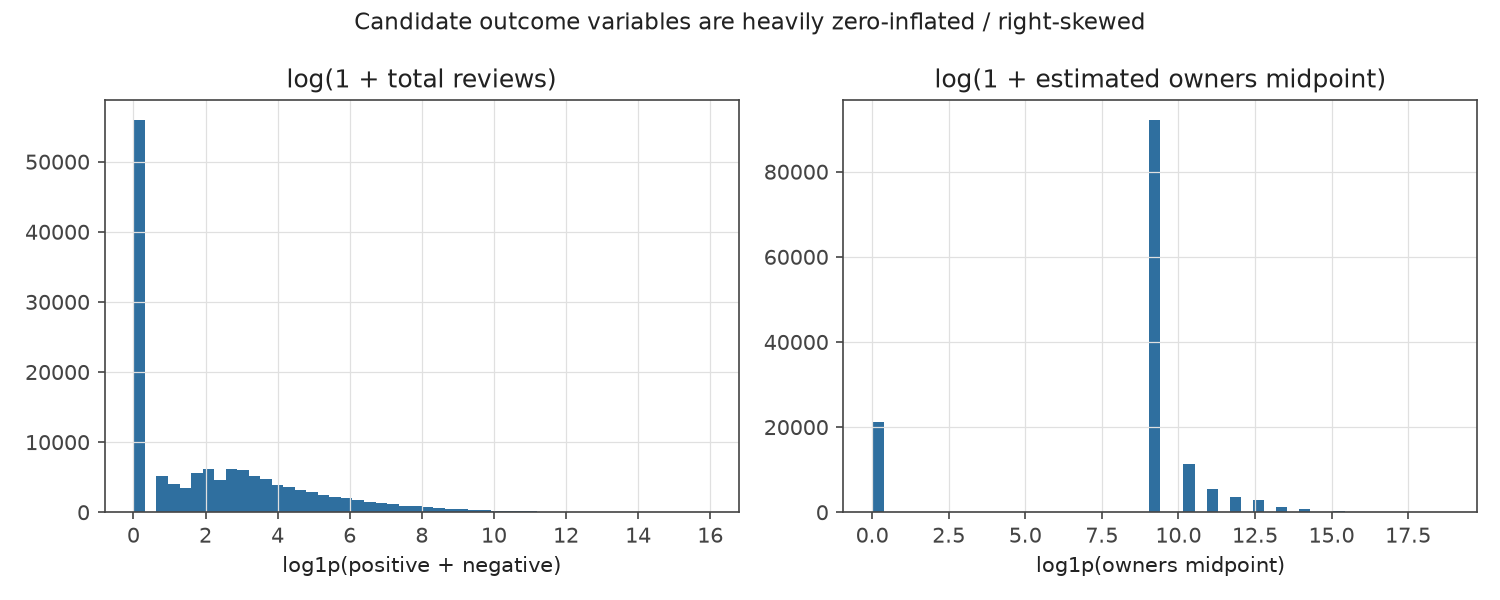

In [32]:
Image(filename=f"{FIG_DIR}/04_candidate_outcome_distributions.png")


**Result:** both `_total_reviews` and `_owners_mid` are heavily zero-inflated / right-skewed even on a log scale. **Interpretation:** any future modeling use needs an explicit zero-handling and skew strategy (hurdle model, log1p, or rank-based target) — this is descriptive confirmation, not a modeling decision made here.

## 13. Feature role & leakage audit

The full per-column classification is saved to [`outputs/feature_role_audit.csv`](../outputs/feature_role_audit.csv). A summary view:

In [33]:
feature_audit = pd.read_csv("../outputs/feature_role_audit.csv")
feature_audit['leakage_risk'].value_counts()


leakage_risk
none                  12
low                   12
high                   9
moderate               6
low-moderate           2
low (data quality)     1
Name: count, dtype: int64

In [34]:
feature_audit[feature_audit['leakage_risk'] == 'high'][['feature', 'role', 'notes']]


,feature,role,notes
5,estimated_owners,ownership/popularity outcome,Coarse current-snapshot bucket (27 unique rang...
11,positive,review outcome,Cumulative lifetime positive-review count; gro...
12,negative,review outcome,Cumulative lifetime negative-review count; sam...
13,recommendations,review outcome,84% zero-inflated; cumulative; 21.9% missing.
14,peak_ccu,engagement outcome,All-time peak concurrent users; a lifetime-to-...
17,average_playtime_forever,engagement outcome,91.4% zero; cumulative lifetime average playti...
18,median_playtime_forever,engagement outcome,Median is 0 in essentially every release-year ...
19,average_playtime_2weeks,engagement outcome,"Reflects current 2-week activity window, not h..."
20,median_playtime_2weeks,engagement outcome,Same rolling-window leakage concern as average...


**Result:** the highest-leakage-risk columns are exactly the popularity/engagement outcomes discussed above (`estimated_owners`, `positive`, `negative`, `recommendations`, `peak_ccu`, `average_playtime_forever` and its variants) — all current cumulative values. `price`/`price_status`/`packages`/`steam_store_available` are marked ambiguous/moderate risk because they reflect current, not launch-time, state.

**Interpretation:** this table is the concrete reference for Phase 2 feature engineering — it should be consulted before adding any column to a model.

## 14. Module feasibility assessment

Full detail and rationale: [`outputs/feasibility_summary.md`](../outputs/feasibility_summary.md). Summary:

| Module | Status | Why |
|---|---|---|
| **Steam Market Analytics** | **GO** | Full catalog, clean genre/price/platform metadata once normalized. Owners bucketing is coarse; price is current not launch. |
| **Review Intelligence / NLP** | **MODIFY** (scope down) | Real content is ~28.6k short critic/press quotes over 9.4% of the catalog, not up to 100 player reviews per game. Reframe as a small "Critical Reception Signal" feature set, not full NLP/topic modeling. |
| **Game Success Modeling** | **MODIFY** (hard constraints) | Every outcome candidate is a current cumulative snapshot with a confirmed severe exposure-time confound. Prospective "predict success at launch" is not defensible with a single-snapshot dataset. Reframe around exposure-time-normalized or age-cohort-matched description. |
| **Content-Based Game Similarity / Recommendation** | **GO** (content-based only) | Genres/categories/tags/descriptions support similarity; no user-game interaction data exists anywhere, so collaborative filtering is categorically out of scope. |

**These are Phase 1 recommendations, not final commitments** — Phase 2 should re-confirm scope against this evidence before implementation.

## 15. Summary & next steps

Phase 1 found the dataset materially different from its documentation in two important ways: (1) the review file contains short critic/press pull-quotes, not player reviews, at a much smaller scale and coverage than documented; (2) the game-level popularity/engagement fields are current cumulative snapshot values with a severe, confirmed exposure-time confound, ruling out naive "predict success at launch" framing.

The catalog metadata itself (genres, categories, tags, price, platform, developer/publisher) is clean enough, after normalizing two mixed serialization formats, to strongly support descriptive market analytics and content-based similarity work. Success modeling and review-based NLP remain viable but require significantly narrower framing than originally proposed.

**Next step:** Phase 2 scoping should start from `outputs/feasibility_summary.md`'s "Recommended Changes to Project Roadmap" and "Open Questions" sections.